In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install tensorflow.keras
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [3]:
img_height = 224
img_width = 224
batch_size = 16
epochs = 200

In [4]:
def process_path(file_path, label):
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [img_height, img_width])
    image = tf.keras.applications.vgg16.preprocess_input(image)
    return image, label


In [5]:
def load_data(data_dir, le=None, max_samples=None):
    csv_path = os.path.join(data_dir, '_annotations.csv')
    df = pd.read_csv(csv_path)
    if max_samples is not None:
        df = df.sample(n=max_samples, random_state=42).reset_index(drop=True)
    file_paths = [os.path.join(data_dir, fname) for fname in df['filename']]
    labels = df['class'].values
    if le is None:
        le = LabelEncoder()
        labels = le.fit_transform(labels)
    else:
        labels = le.transform(labels)
    return file_paths, labels, le


In [6]:
base_dir = "/content/drive/MyDrive"
train_dir = os.path.join(base_dir, "train")
valid_dir = os.path.join(base_dir, "valid")
test_dir  = os.path.join(base_dir, "test")

train_paths, train_labels, le = load_data(train_dir, le=None, max_samples=420)
valid_paths, valid_labels, _ = load_data(valid_dir, le=le)
test_paths, test_labels, _   = load_data(test_dir, le=le)

num_classes = len(np.unique(train_labels))
print("number of classes :", num_classes)

number of classes : 3


In [7]:
def get_dataset(file_paths, labels, batch_size=batch_size, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    ds = ds.map(lambda x, y: process_path(x, y), num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(file_paths))
    ds = ds.batch(batch_size)
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)
    return ds

train_ds = get_dataset(train_paths, train_labels, batch_size=batch_size, shuffle=True)
valid_ds = get_dataset(valid_paths, valid_labels, batch_size=batch_size, shuffle=False)
test_ds  = get_dataset(test_paths, test_labels, batch_size=batch_size, shuffle=False)


In [8]:
base_model = tf.keras.applications.VGG16(weights='imagenet',
                                         include_top=False,
                                         input_shape=(img_height, img_width, 3))
base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [9]:
!pip install tqdm

from tqdm.keras import TqdmCallback

learning_rate = 1e-4

optimizer = tf.keras.optimizers.AdamW(learning_rate=learning_rate)

model.compile(optimizer=optimizer,
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    TqdmCallback(verbose=1)
]

history = model.fit(train_ds,
                    validation_data=valid_ds,
                    epochs=epochs,
                    callbacks=callbacks)

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Epoch 1/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.6046 - loss: 4.2281 - val_accuracy: 0.8710 - val_loss: 2.5702 - learning_rate: 1.0000e-04
Epoch 2/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 58s 497ms/step - accuracy: 0.6945 - loss: 3.6915 - val_accuracy: 0.8710 - val_loss: 2.0421 - learning_rate: 1.0000e-04
Epoch 3/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 285ms/step - accuracy: 0.6739 - loss: 2.8028 - val_accuracy: 0.8710 - val_loss: 1.8493 - learning_rate: 1.0000e-04
Epoch 4/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 301ms/step - accuracy: 0.6867 - loss: 3.0921 - val_accuracy: 0.8710 - val_loss: 1.6750 - learning_rate: 1.0000e-04
Epoch 5/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 299ms/step - accuracy: 0.6838 - loss: 2.5325 - val_accuracy: 0.8710 - val_loss: 1.6245 - learning_rate: 1.0000e-04
Epoch 6/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 270ms/step - accuracy: 0.7269 - loss: 2.3984 - val_accuracy: 0.8710 - val_loss: 1.4282 - learning_rate: 1.0000e-04
Epoch 7/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 287ms/step - 

19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 774ms/step - accuracy: 0.8101 - loss: 0.8932
loss of test: 0.6469787359237671
accurecy of test : 0.846666693687439


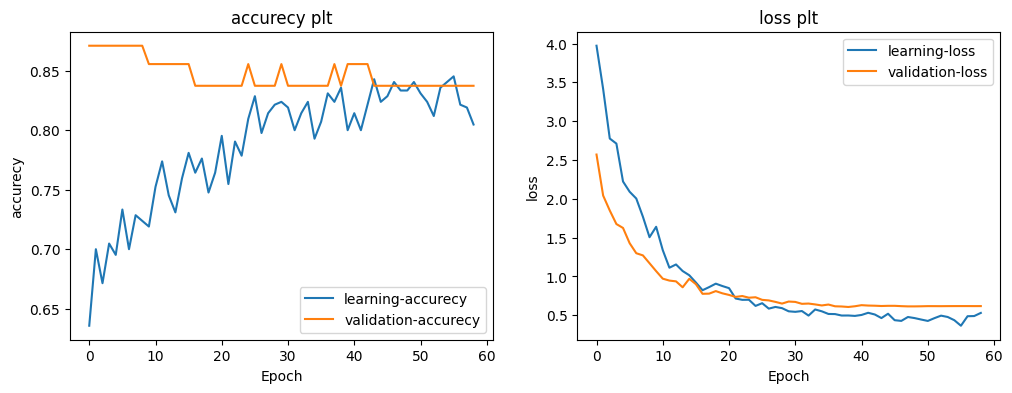

In [10]:

test_loss, test_acc = model.evaluate(test_ds)
print("loss of test:", test_loss)
print("accurecy of test :", test_acc)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='learning-accurecy')
plt.plot(history.history['val_accuracy'], label='validation-accurecy')
plt.title("accurecy plt")
plt.xlabel("Epoch")
plt.ylabel("accurecy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='learning-loss')
plt.plot(history.history['val_loss'], label='validation-loss')
plt.title("loss plt")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.legend()

plt.show()


In [13]:
model.save("toothdecay_VGG16_model.h5")

In [16]:
from tensorflow.keras.applications.vgg16 import preprocess_input
from PIL import Image

img_height = 224
img_width = 224

model = tf.keras.models.load_model("toothdecay_VGG16_model.h5")

class_names = ['Without-Caries', 'Caries-Meduim', 'Caries-Extensive']

def load_and_preprocess_image(img_path):
    img_raw = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img_raw, channels=3)
    img = tf.image.resize(img, [img_height, img_width])
    img = preprocess_input(img)
    return img

folder_path = "/content/drive/MyDrive/test"

image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

for img_name in image_files:
    img_path = os.path.join(folder_path, img_name)

    img = load_and_preprocess_image(img_path)
    img_batch = np.expand_dims(img, axis=0)

    predictions = model.predict(img_batch)[0]

    predicted_index = np.argmax(predictions)
    predicted_class = class_names[predicted_index]
    confidence = predictions[predicted_index]

    pil_img = Image.open(img_path)
    plt.imshow(pil_img)
    plt.axis('off')

    prediction_text = "\n".join([f"{class_names[i]}: {predictions[i]*100:.2f}%" for i in range(len(class_names))])

    plt.title(f"Prediction: {predicted_class} ({confidence*100:.2f}%)\n{prediction_text}")
    plt.show()

Output hidden; open in https://colab.research.google.com to view.